# 04 - Modeling: Churn Prediction (With vs Without Customer Segmentation)
### Customer Churn Prediction in the Banking Sector

This is the core notebook. Following the paper's pipeline, we:

1. Load the segmented dataset (from notebook 03)
2. Build a reusable pipeline: **train/test split → SMOTE balancing → train 5 models → evaluate**
3. Run this pipeline on:
   - The **full ("Original") dataset** (no segmentation)
   - **Each of the 6 clusters separately** (with segmentation)
4. Models: **KNN, Logistic Regression, Decision Tree, Random Forest, SVM**
5. Metrics: **Accuracy, Precision, Recall, F1-score** (hold-out 70/30 split)
6. Compare "Sample" (no segmentation) vs "Cluster average" (with segmentation) — reproducing
   Figures 5-8 from the paper
7. Save the best model + all metrics to disk


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    raise ImportError("Please install imbalanced-learn: pip install imbalanced-learn")

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42


## 1. Load Segmented Data

In [2]:
DATA_PATH = "../data/processed/churn_segmented.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (7081, 34)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Education_Level_Doctorate,Education_Level_Graduate,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Marital_Status_Married,Marital_Status_Single,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Cluster,Cluster_Label
0,0,-0.167610,1,3,0.377234,5,1,3,0.340190,0.308701,0.345116,1.335,0.036260,0.258065,1.625,0.061,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,3,IV
1,0,0.329862,0,5,1.002074,6,1,2,0.206112,0.343266,0.214093,1.541,0.044667,0.185484,3.714,0.105,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,False,2,III
2,0,0.578598,1,3,0.002330,4,1,0,0.059850,0.000000,0.098948,2.594,0.078753,0.080645,2.333,0.000,False,True,False,False,False,True,False,False,False,False,True,False,True,False,False,False,2,III
3,0,-0.789449,1,3,-1.872192,5,1,0,0.099091,0.000000,0.136557,2.175,0.017501,0.145161,2.500,0.000,False,False,False,False,True,True,False,False,False,True,False,False,True,False,False,False,2,III
4,0,-0.291978,1,2,0.002330,3,1,2,0.077747,0.495431,0.079970,1.376,0.033057,0.112903,0.846,0.311,False,True,False,False,False,True,False,False,True,False,False,False,True,False,False,False,4,V


## 2. Define Models

Same 5 classifiers used in the paper. Parameters kept close to scikit-learn defaults with a
few sensible tweaks (e.g., `class_weight` left untouched since SMOTE already balances classes).


In [3]:
def get_models():
    return {
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'LR': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'DT': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'RF': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    }


## 3. Reusable Train/Evaluate Function

For a given dataset (full data or one cluster):
1. Split features/target
2. 70/30 train/test split (hold-out, matches the paper)
3. Apply **SMOTE only on the training set** (never on test data — avoids data leakage)
4. Train each of the 5 models
5. Evaluate on the untouched test set → accuracy, precision, recall, F1


In [4]:
def train_evaluate(X, y, label='Original', verbose=True):
    """
    Trains and evaluates all 5 models on a given X, y.
    Returns a DataFrame of results and a dict of fitted models.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )

    # Apply SMOTE only on training data
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    if verbose:
        print(f"[{label}] Train before SMOTE: {y_train.value_counts().to_dict()}")
        print(f"[{label}] Train after  SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")
        print(f"[{label}] Test set (untouched): {y_test.value_counts().to_dict()}")

    results = []
    fitted_models = {}

    for name, model in get_models().items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred) * 100
        prec = precision_score(y_test, y_pred, zero_division=0) * 100
        rec = recall_score(y_test, y_pred, zero_division=0) * 100
        f1 = f1_score(y_test, y_pred, zero_division=0) * 100

        results.append({
            'Dataset': label, 'Model': name,
            'Accuracy': round(acc, 2), 'Precision': round(prec, 2),
            'Recall': round(rec, 2), 'F1_Score': round(f1, 2)
        })
        fitted_models[name] = model

    return pd.DataFrame(results), fitted_models, (X_test, y_test)


## 4. Run A — Churn Prediction WITHOUT Segmentation (Full Dataset)


In [5]:
feature_cols = [c for c in df.columns if c not in
                ['Attrition_Flag', 'Cluster', 'Cluster_Label']]

X_full = df[feature_cols]
y_full = df['Attrition_Flag']

results_original, models_original, testset_original = train_evaluate(
    X_full, y_full, label='Original'
)
results_original


  File "c:\Users\adity\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\adity\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\adity\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\adity\anaconda3\Lib\subprocess.

[Original] Train before SMOTE: {0: 4177, 1: 779}
[Original] Train after  SMOTE: {0: 4177, 1: 4177}
[Original] Test set (untouched): {0: 1791, 1: 334}


,Dataset,Model,Accuracy,Precision,Recall,F1_Score
0,Original,KNN,74.12,31.57,55.39,40.22
1,Original,LR,88.33,61.14,70.66,65.56
2,Original,DT,92.24,71.18,85.03,77.49
3,Original,RF,94.73,81.90,85.33,83.58
4,Original,SVM,88.05,60.70,67.96,64.12


## 5. Run B — Churn Prediction WITH Segmentation (Per Cluster)

In [6]:
cluster_results_list = []
cluster_models = {}

for cluster_label in sorted(df['Cluster_Label'].unique()):
    cluster_df = df[df['Cluster_Label'] == cluster_label]
    X_c = cluster_df[feature_cols]
    y_c = cluster_df['Attrition_Flag']

    res, fitted, _ = train_evaluate(X_c, y_c, label=f'Cluster_{cluster_label}', verbose=False)
    res['Cluster'] = cluster_label
    cluster_results_list.append(res)
    cluster_models[cluster_label] = fitted

    print(f"Cluster {cluster_label}: n={len(cluster_df)}, churn rate={y_c.mean()*100:.2f}%  -> done")

results_clusters = pd.concat(cluster_results_list, ignore_index=True)
results_clusters


Cluster I: n=950, churn rate=13.26%  -> done
Cluster II: n=1055, churn rate=23.60%  -> done
Cluster III: n=1199, churn rate=8.09%  -> done
Cluster IV: n=1222, churn rate=17.35%  -> done
Cluster V: n=1610, churn rate=20.12%  -> done
Cluster VI: n=1045, churn rate=10.05%  -> done


,Dataset,Model,Accuracy,Precision,Recall,F1_Score,Cluster
0,Cluster_I,KNN,78.60,29.82,44.74,35.79,I
1,Cluster_I,LR,87.72,54.05,52.63,53.33,I
2,Cluster_I,DT,90.53,63.41,68.42,65.82,I
3,Cluster_I,RF,93.68,85.71,63.16,72.73,I
4,Cluster_I,SVM,87.37,52.78,50.00,51.35,I
5,Cluster_II,KNN,74.13,46.32,58.67,51.76,II
6,Cluster_II,LR,89.59,75.61,82.67,78.98,II
7,Cluster_II,DT,89.91,76.54,82.67,79.49,II
8,Cluster_II,RF,94.64,87.18,90.67,88.89,II
9,Cluster_II,SVM,85.80,70.27,69.33,69.80,II


## 6. Aggregate: Cluster Average vs Sample (Original)

This reproduces the "Sample" vs "Cluster average" comparison from Figures 5-8 in the paper.


In [7]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']

# Cluster average per model
cluster_avg = results_clusters.groupby('Model')[metrics].mean().round(2)
cluster_avg = cluster_avg.reset_index().rename(columns={m: f'{m}_ClusterAvg' for m in metrics})

# Sample (original, no segmentation) per model
sample = results_original.set_index('Model')[metrics].round(2)
sample = sample.reset_index().rename(columns={m: f'{m}_Sample' for m in metrics})

comparison = sample.merge(cluster_avg, on='Model')
# Reorder columns nicely
ordered_cols = ['Model']
for m in metrics:
    ordered_cols += [f'{m}_Sample', f'{m}_ClusterAvg']
comparison = comparison[ordered_cols]
comparison


,Model,Accuracy_Sample,Accuracy_ClusterAvg,Precision_Sample,Precision_ClusterAvg,Recall_Sample,Recall_ClusterAvg,F1_Score_Sample,F1_Score_ClusterAvg
0,KNN,74.12,74.68,31.57,28.72,55.39,45.44,40.22,34.77
1,LR,88.33,89.26,61.14,59.14,70.66,63.64,65.56,60.90
2,DT,92.24,90.88,71.18,65.42,85.03,77.18,77.49,70.42
3,RF,94.73,94.16,81.90,81.51,85.33,73.25,83.58,76.75
4,SVM,88.05,87.41,60.70,54.53,67.96,60.86,64.12,56.99


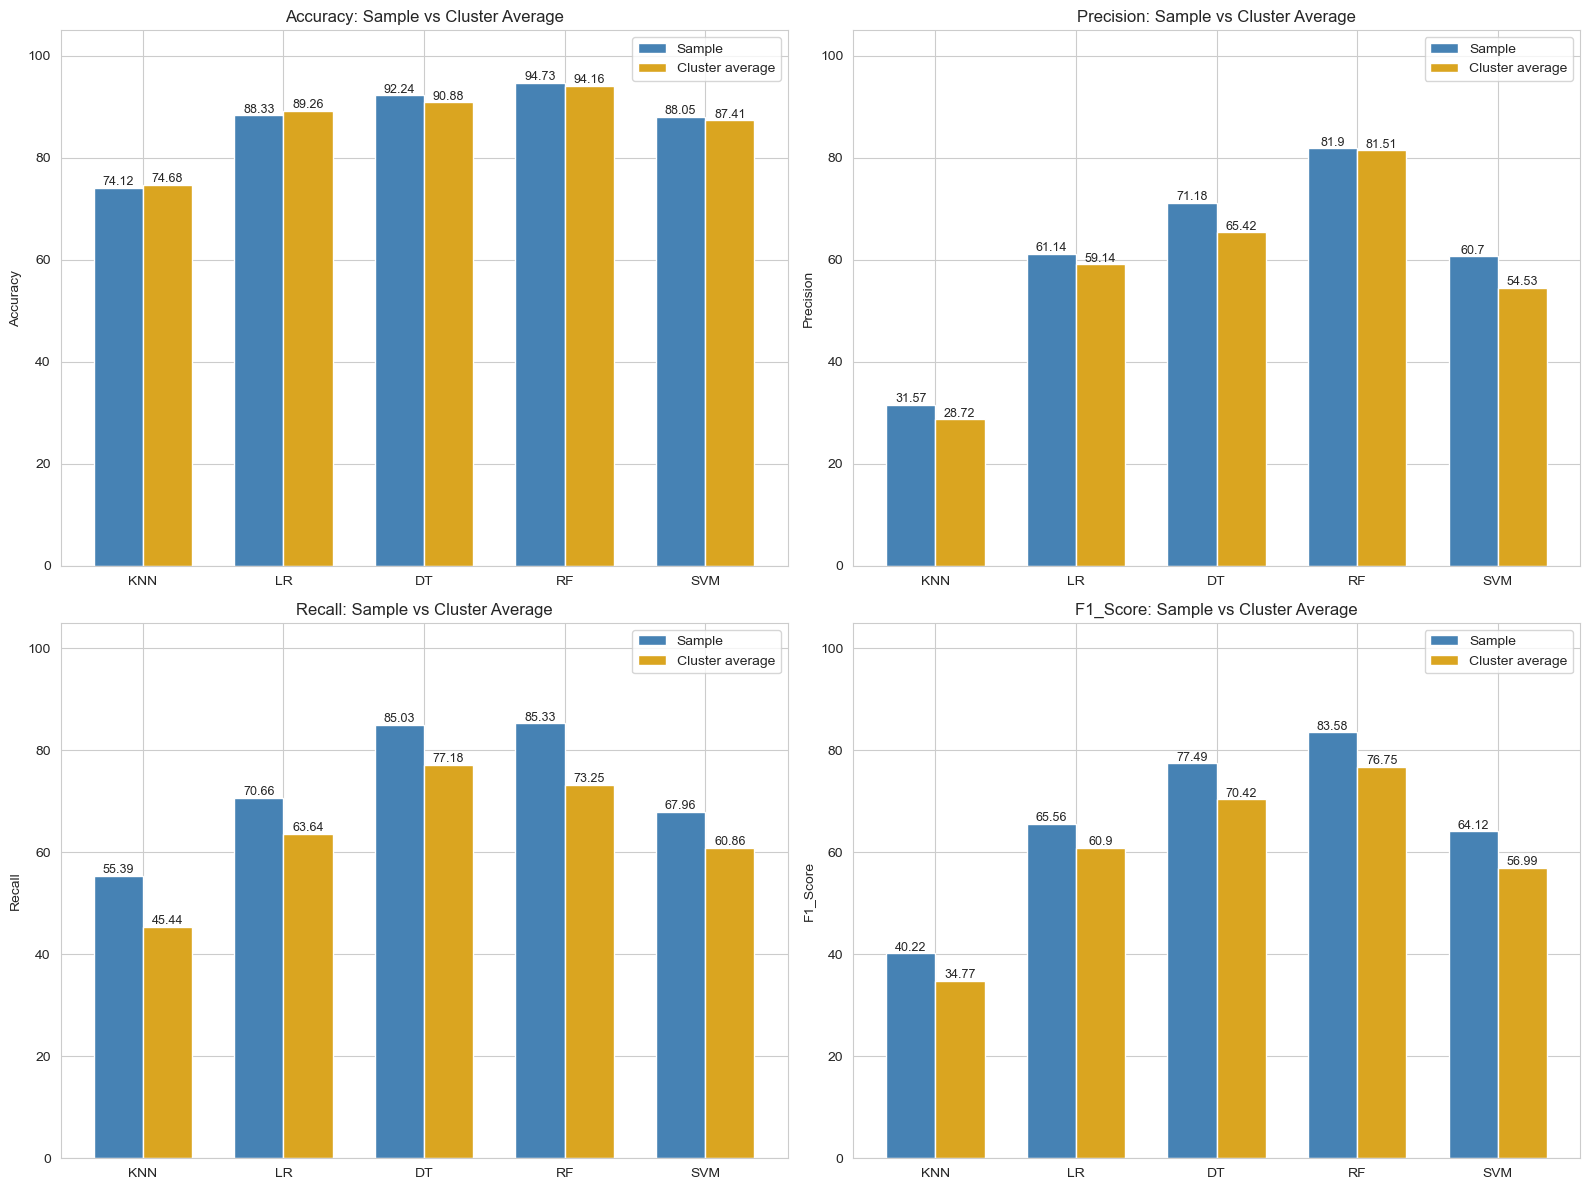

In [8]:
# Plot Sample vs Cluster Average for each metric (matches paper's Figures 5-8)
model_order = ['KNN', 'LR', 'DT', 'RF', 'SVM']
comparison = comparison.set_index('Model').reindex(model_order).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    x = np.arange(len(comparison))
    width = 0.35

    ax.bar(x - width/2, comparison[f'{metric}_Sample'], width, label='Sample', color='steelblue')
    ax.bar(x + width/2, comparison[f'{metric}_ClusterAvg'], width, label='Cluster average', color='goldenrod')

    for i, v in enumerate(comparison[f'{metric}_Sample']):
        ax.text(i - width/2, v + 0.5, f'{v}', ha='center', fontsize=9)
    for i, v in enumerate(comparison[f'{metric}_ClusterAvg']):
        ax.text(i + width/2, v + 0.5, f'{v}', ha='center', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(comparison['Model'])
    ax.set_title(f'{metric}: Sample vs Cluster Average')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 105)
    ax.legend()

plt.tight_layout()
plt.show()


## 7. Detailed Cluster Results Table (Matches Paper's Table 5)


In [9]:
detailed_table = results_clusters.pivot_table(
    index=['Model', 'Cluster'], values=metrics
).reset_index()
detailed_table = detailed_table.sort_values(['Model', 'Cluster'])
detailed_table


,Model,Cluster,Accuracy,F1_Score,Precision,Recall
0,DT,I,90.53,65.82,63.41,68.42
1,DT,II,89.91,79.49,76.54,82.67
2,DT,III,92.22,61.11,51.16,75.86
3,DT,IV,87.47,68.92,60.71,79.69
4,DT,V,94.41,85.86,87.23,84.54
5,DT,VI,90.76,61.33,53.49,71.88
6,KNN,I,78.60,35.79,29.82,44.74
7,KNN,II,74.13,51.76,46.32,58.67
8,KNN,III,78.61,25.24,17.57,44.83
9,KNN,IV,64.85,25.43,20.18,34.38


## 8. Which Model Wins? Best Overall Model


In [10]:
best_row = results_original.sort_values('F1_Score', ascending=False).iloc[0]
print("Best model on full (Original) dataset by F1-score:")
print(best_row)

best_model_name = best_row['Model']
print(f"\n--> Best model: {best_model_name}")


Best model on full (Original) dataset by F1-score:
Dataset      Original
Model              RF
Accuracy        94.73
Precision        81.9
Recall          85.33
F1_Score        83.58
Name: 3, dtype: object

--> Best model: RF


## 9. Confusion Matrix & Classification Report for Best Model

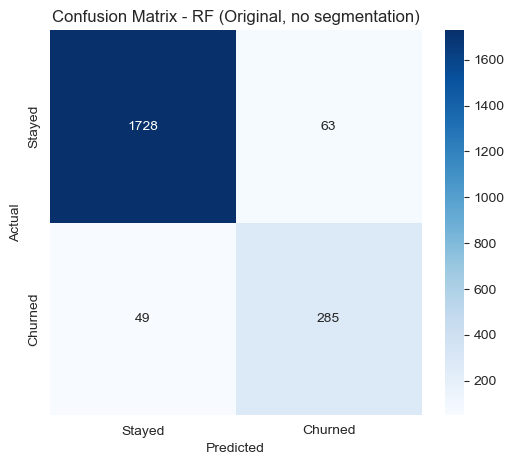

              precision    recall  f1-score   support

      Stayed       0.97      0.96      0.97      1791
     Churned       0.82      0.85      0.84       334

    accuracy                           0.95      2125
   macro avg       0.90      0.91      0.90      2125
weighted avg       0.95      0.95      0.95      2125



In [11]:
best_model = models_original[best_model_name]
X_test, y_test = testset_original
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title(f'Confusion Matrix - {best_model_name} (Original, no segmentation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Churned']))


## 10. Feature Importance (Random Forest)

Even if RF isn't the single best model, it's useful to inspect feature importances —
this can guide the "which feature drives churn most" follow-up research mentioned in the paper.


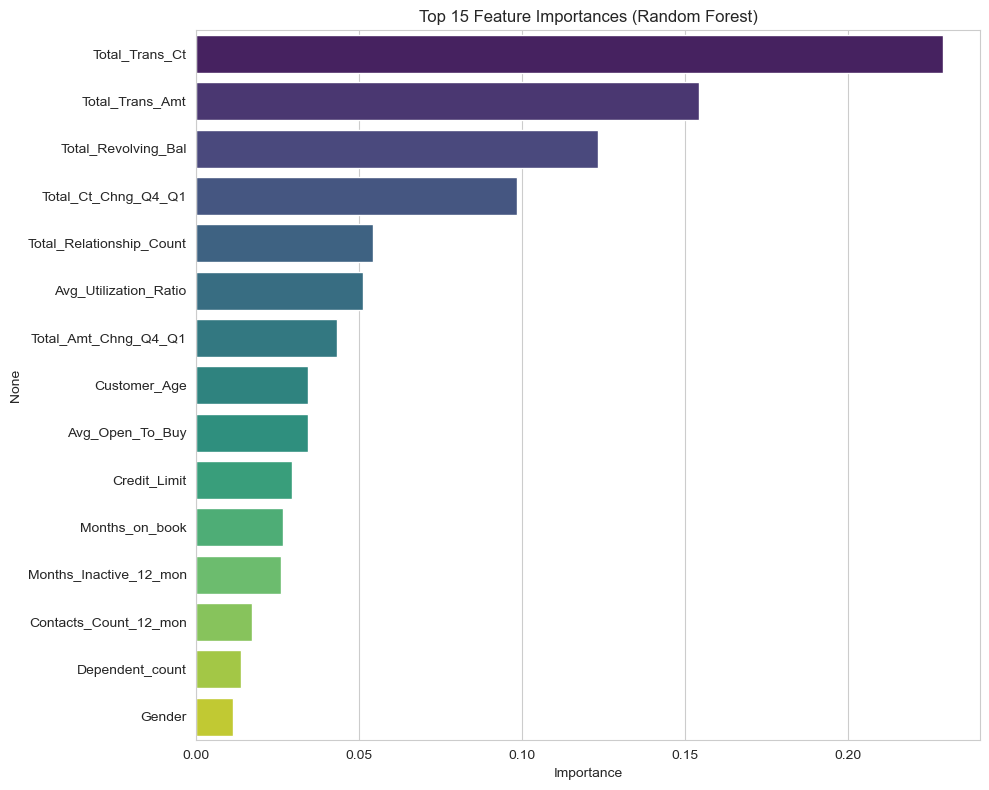

In [12]:
rf_model = models_original['RF']

importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 11. Save Results & Best Model

In [13]:
os.makedirs("../outputs/metrics", exist_ok=True)
os.makedirs("../models/saved_models", exist_ok=True)

results_original.to_csv("../outputs/metrics/results_original.csv", index=False)
results_clusters.to_csv("../outputs/metrics/results_clusters.csv", index=False)
comparison.to_csv("../outputs/metrics/sample_vs_cluster_avg.csv", index=False)

joblib.dump(best_model, f"../models/saved_models/best_model_{best_model_name}.pkl")
joblib.dump(feature_cols, "../models/saved_models/feature_columns.pkl")

print("Saved:")
print(" - outputs/metrics/results_original.csv")
print(" - outputs/metrics/results_clusters.csv")
print(" - outputs/metrics/sample_vs_cluster_avg.csv")
print(f" - models/saved_models/best_model_{best_model_name}.pkl")
print(" - models/saved_models/feature_columns.pkl")


Saved:
 - outputs/metrics/results_original.csv
 - outputs/metrics/results_clusters.csv
 - outputs/metrics/sample_vs_cluster_avg.csv
 - models/saved_models/best_model_RF.pkl
 - models/saved_models/feature_columns.pkl


## Summary

- Built a reusable **SMOTE + train/evaluate** pipeline applied to both the full dataset
  and each of the 6 customer segments.
- Compared **5 models** (KNN, LR, DT, RF, SVM) using Accuracy, Precision, Recall, F1.
- Reproduced the paper's core finding: **Random Forest performs best overall**, and
  **customer segmentation does not consistently improve prediction accuracy** — results
  depend on the dataset and model choice, matching the paper's conclusion.
- Saved the best-performing model and all metric tables for use in the demo app and README.

➡️ **Next:** `05_results_comparison.ipynb` — consolidate all results into final
publication-style charts and tables for the README/report, and (optionally) build the
Streamlit demo app (`app/streamlit_app.py`) using the saved model.
